<a href="https://colab.research.google.com/github/Dalbeth/Data-Science-Cohort-20/blob/main/Images_DogsCats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Images – Classifying cat and dog images using a convolutional neural net (CNN)

Kimberly Butler



Prior to starting this problem, be sure to enable the GPU runtime processing in your Jupyter notebook.



## Problem Definition


This project will train a CNN to differentiate dog pictures from cat pictures using a pre-labeled dataset.  The goal of this project is the creation of a model that can catergorize an unseen dog or cat picture with greater than 75% accuracy.



In [ ]:
import tensorflow.keras as keras
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from keras.models import Sequential
from keras.layers import Dense, Input, Flatten, Conv2D, MaxPooling2D
from keras.utils import plot_model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import seaborn as sns
from sklearn.metrics import confusion_matrix
import io
import requests
from tensorflow.keras.preprocessing.image import img_to_array, load_img

## Data Collection



The data is provided at the following links:

https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle

https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle

https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg

The first 2 links are the X and y pickle files and the final file is the hold out image for testing accuracy of the model.

In [ ]:
images_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle"
images_url

'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle'

In [ ]:
image_array = pd.read_pickle( images_url )
type(image_array)

numpy.ndarray

In [ ]:
image_array.shape

(24946, 100, 100, 1)

In [ ]:
target_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle"
target_url

'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle'

In [ ]:
target = pd.read_pickle( target_url )
type(target)

list

In [ ]:
target_array = np.array(target)
type(target_array)

numpy.ndarray

In [ ]:
target_array.shape

(24946,)

## Data Cleaning



* Scale the values in X so that they fall between 0 and 1 by dividing by 255.



In [ ]:
sized_array = image_array / 255

In [ ]:
sized_array

array([[[[0.37254902],
         [0.36862745],
         [0.38431373],
         ...,
         [0.66666667],
         [0.6745098 ],
         [0.67058824]],

        [[0.36078431],
         [0.35686275],
         [0.37254902],
         ...,
         [0.66666667],
         [0.6745098 ],
         [0.67058824]],

        [[0.34901961],
         [0.35686275],
         [0.36078431],
         ...,
         [0.64705882],
         [0.6627451 ],
         [0.6627451 ]],

        ...,

        [[0.32941176],
         [0.29803922],
         [0.28627451],
         ...,
         [0.52941176],
         [0.64313725],
         [0.60392157]],

        [[0.32156863],
         [0.30980392],
         [0.27843137],
         ...,
         [0.55686275],
         [0.5254902 ],
         [0.6       ]],

        [[0.31372549],
         [0.33333333],
         [0.33333333],
         ...,
         [0.59215686],
         [0.57254902],
         [0.54117647]]],


       [[[0.67058824],
         [0.60392157],
         [0.54

## Exploratory Data Analysis



* Look at the shape of X and y. Ensure that X is 4 dimensional.

* Plot a few ( >5 ) of the images in X using `plt.imshow()`.

* Look at the response values in y for those images.

* Hint: you may want to start with a random subset to get familiar with the process of building a NN.  Then go through the process again with the full set.



In [ ]:
sized_array.shape

(24946, 100, 100, 1)

In [ ]:
target_array.shape

(24946,)

0


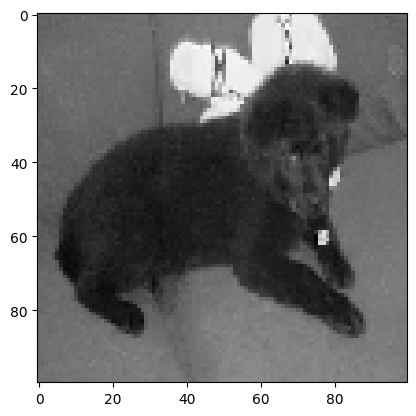

0


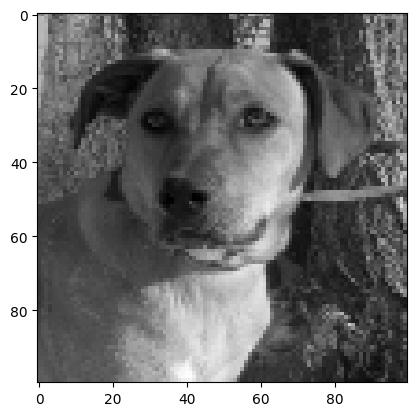

1


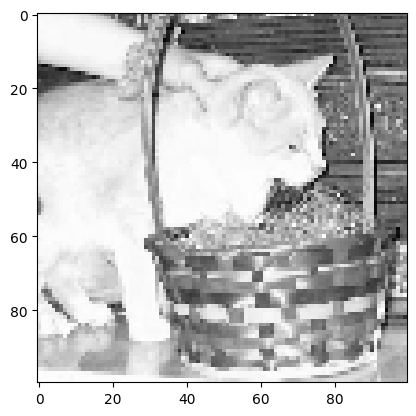

0


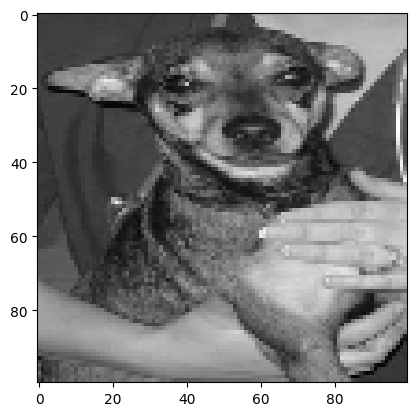

1


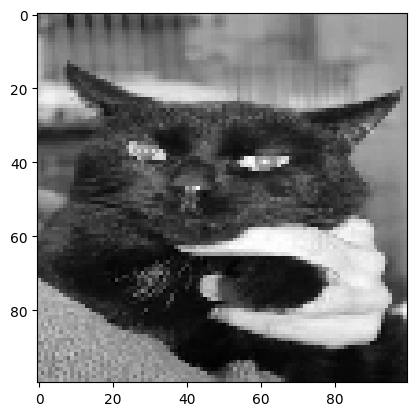

0


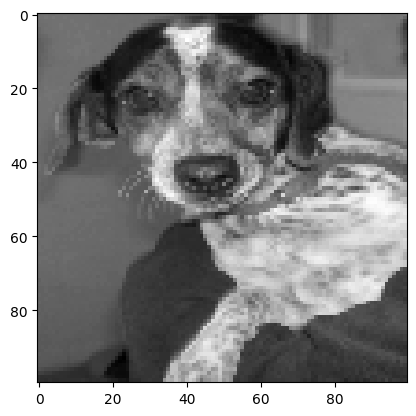

0


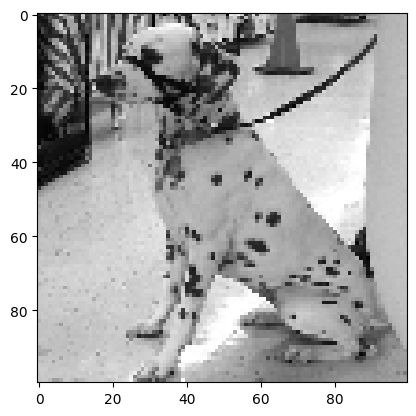

1


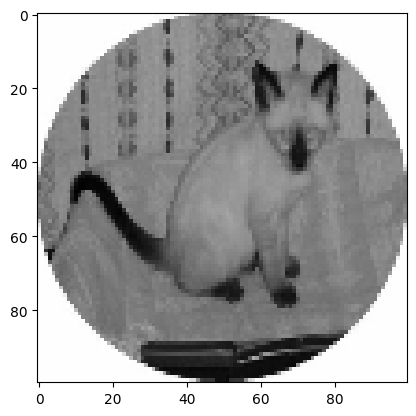

1


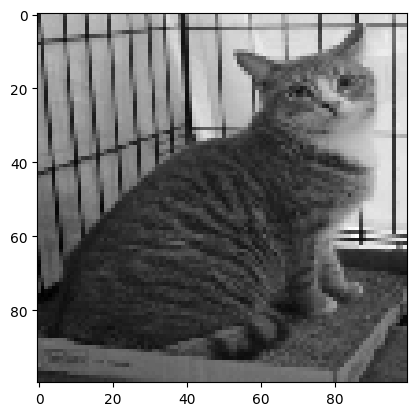

0


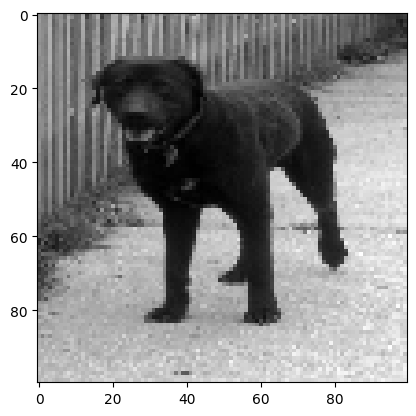

In [ ]:
random_indices = np.random.choice(
    len(image_array),
    size=10,
    replace=False
)

for i in random_indices:
    print(target_array[i])
    plt.imshow(image_array[i], cmap="gray")
    plt.show()

## Data Processing



* Split X and y into training and testing sets.

*  Build a convolutional neural network with the following:
  * Sequential layers
  * At least two 2D convolutional layers using the 'relu' activation function and a (3,3) kernel size.
  * A MaxPooling2D layer after each 2D convolutional layer that has a pool size of (2,2).
  * A dense output layer using the 'sigmoid' activation function.
  Note: you can play around with the number of layers and nodes to try to get better performance.

* Compile your model. Use the 'adam' optimizer. Determine which loss function and metric is most appropriate for this problem.

* Fit your model using the training set.

* Evaluate your model using the testing set.

* Plot the distribution of probabilities for the testing set.

* Define a function that will read in a new image and convert it to a 4 dimensional array of pixels (ask the instructor for help with this). Hint: [numpy.reshape]( https://numpy.org/doc/stable/reference/generated/numpy.reshape.html )

* Use the function defined above to read in the dog.jpg image that is saved in the AWS S3 bucket.

* Use the neural network you created to predict whether the image is a dog or a cat.



In [ ]:
X_train, X_test, y_train, y_test = train_test_split( sized_array, target_array, test_size = 0.2 )

In [ ]:
model = Sequential()

# Define input layer
model.add(
  Input(
    shape=X_train.shape[1:],
    name="input",
  ),
)

# Define hidden layer 1
model.add(
  Conv2D(
    name = "Conv2Dnum1",
    filters = 64,
    kernel_size = (3,3),
    activation = 'relu',
  )
)

model.add(
  MaxPooling2D(pool_size=(2,2))
)


# Define hidden layer 2
model.add(
  Conv2D(
    name = "Conv2Dnum2",
    filters = 64,
    kernel_size = (3,3),
    activation = 'relu',
  )
)

model.add(
  MaxPooling2D(pool_size=(2,2))
)


# Define hidden layer 3
model.add(
  Conv2D(
    name = "Conv3",
    filters = 64,
    kernel_size = (3,3),
    activation = 'relu',
  )
)

model.add(
  MaxPooling2D(pool_size=(2,2))
)

# Flatten data and pass through classification head
model.add(Flatten(name="flatten"))
model.add(Dense(64, activation="relu", name="dense_hidden"))
model.add(Dropout(0.5, name="regularization"))

# Define single, final output layer
model.add(
  Dense(
    units = 1,
    activation = 'sigmoid',
    name = "output",
  )
)

# Compile model
model.compile(
  optimizer = 'adam',
  loss = 'binary_crossentropy',
  metrics = ['accuracy'],
)

# Verify the final architecture
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv2Dnum1 (Conv2D)             │ (None, 98, 98, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2Dnum2 (Conv2D)             │ (None, 47, 47, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3 (Conv2D)                  │ (None, 21, 21, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 64)             │       409,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ regularization (Dropout)        │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 484,225 (1.85 MB)

 Trainable params: 484,225 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

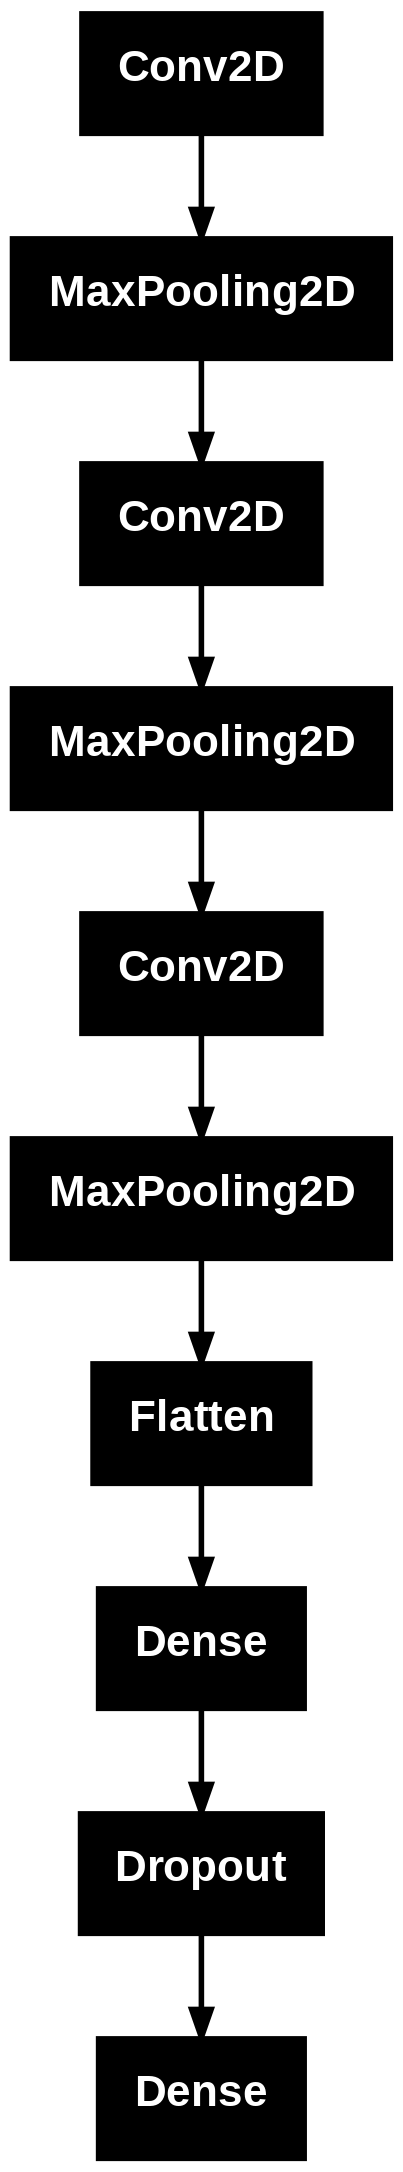

In [ ]:
plot_model(model)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=8,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/8
312/312 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - accuracy: 0.5835 - loss: 0.6630 - val_accuracy: 0.6651 - val_loss: 0.6159
Epoch 2/8
312/312 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.7325 - loss: 0.5407 - val_accuracy: 0.7571 - val_loss: 0.4927
Epoch 3/8
312/312 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.7886 - loss: 0.4561 - val_accuracy: 0.7533 - val_loss: 0.4812
Epoch 4/8
312/312 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.8145 - loss: 0.4155 - val_accuracy: 0.7996 - val_loss: 0.4354
Epoch 5/8
312/312 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.8342 - loss: 0.3766 - val_accuracy: 0.8102 - val_loss: 0.4147
Epoch 6/8
312/312 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.8521 - loss: 0.3405 - val_accuracy: 0.8355 - val_loss: 0.3839
Epoch 7/8
312/312 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.8675 - loss: 0.3091 - val_accuracy: 0.8427 - val_loss: 0.3535
Epoch 8/8
312/312 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.8811 - loss: 0.2847 - val_accuracy: 0

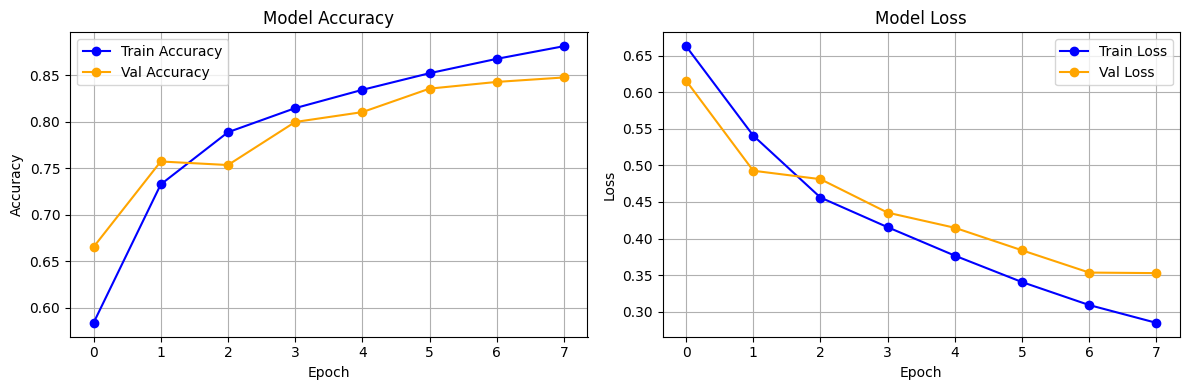

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange', marker='o')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


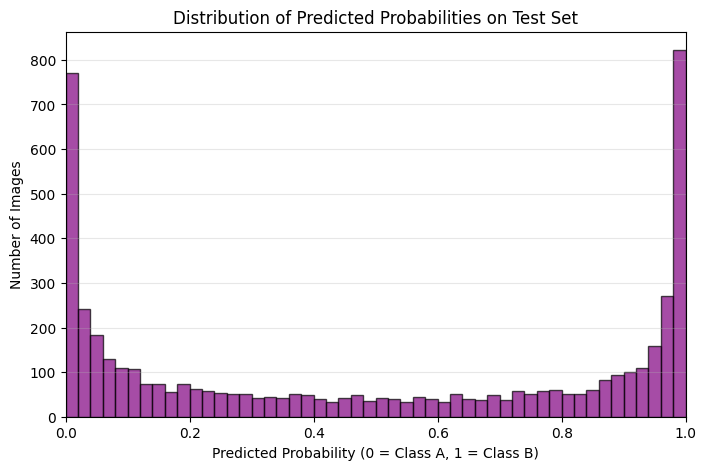

In [ ]:
y_pred_probabilities = model.predict(X_test, batch_size=64)


y_pred_probabilities = y_pred_probabilities.ravel()


plt.figure(figsize=(8, 5))
plt.hist(
    y_pred_probabilities,
    bins=50,
    color='purple',
    edgecolor='black',
    alpha=0.7
)


plt.title('Distribution of Predicted Probabilities on Test Set')
plt.xlabel('Predicted Probability (0 = Class A, 1 = Class B)')
plt.ylabel('Number of Images')
plt.xlim(0, 1)
plt.grid(axis='y', alpha=0.3)

plt.show()

78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


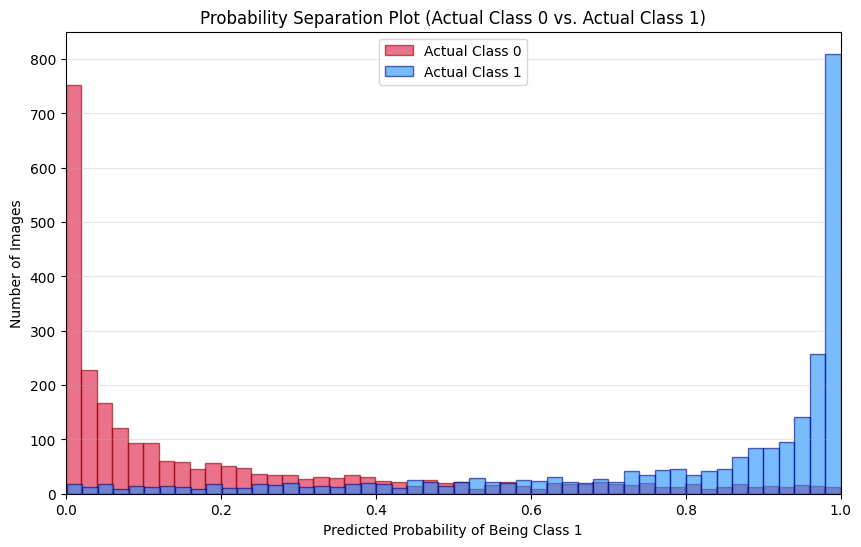

In [ ]:
y_pred_probabilities = model.predict(X_test, batch_size=64).ravel()
y_true_labels = np.array(y_test).ravel()


probs_actual_0 = y_pred_probabilities[y_true_labels == 0]
probs_actual_1 = y_pred_probabilities[y_true_labels == 1]


plt.figure(figsize=(10, 6))


plt.hist(
    probs_actual_0,
    bins=50,
    alpha=0.6,
    color='crimson',
    label='Actual Class 0',
    edgecolor='darkred'
)


plt.hist(
    probs_actual_1,
    bins=50,
    alpha=0.6,
    color='dodgerblue',
    label='Actual Class 1',
    edgecolor='darkblue'
)


plt.title('Probability Separation Plot (Actual Class 0 vs. Actual Class 1)')
plt.xlabel('Predicted Probability of Being Class 1')
plt.ylabel('Number of Images')
plt.xlim(0, 1)
plt.legend(loc='upper center')
plt.grid(axis='y', alpha=0.3)

plt.show()

I asked Gemini how to output this as a confusion matrix and got the code below

78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


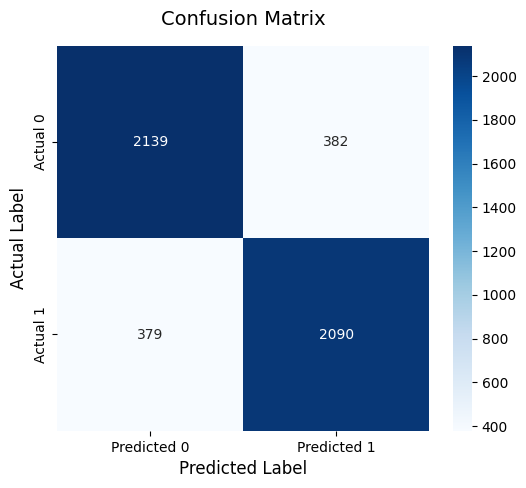

In [ ]:
# 1. Generate predictions and convert probabilities to binary classes (0 or 1)
y_pred_probabilities = model.predict(X_test, batch_size=64).ravel()
y_pred_classes = (y_pred_probabilities >= 0.5).astype(int)
y_true_classes = np.array(y_test).ravel()

# 2. Compute the confusion matrix values
cm = confusion_matrix(y_true_classes, y_pred_classes)

# 3. Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,          # Show the raw counts inside the boxes
    fmt='d',             # Format numbers as integers
    cmap='Blues',        # Use a blue color gradient
    xticklabels=['Predicted 0', 'Predicted 1'],
    yticklabels=['Actual 0', 'Actual 1']
)

# 4. Add formatting labels
plt.title('Confusion Matrix', fontsize=14, pad=15)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


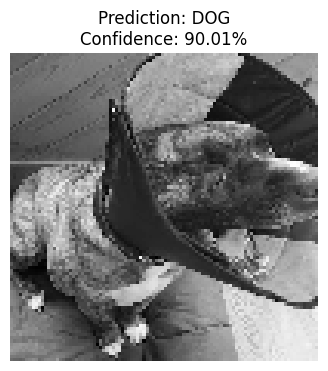

In [ ]:
test_image = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg"

try:
    response = requests.get(test_image, timeout=10)
    image_bytes = io.BytesIO(response.content)

    img = load_img(image_bytes, target_size=(100, 100), color_mode="grayscale")

    img_array = img_to_array(img)
    img_array = img_array / 255.0

    img_batch = np.expand_dims(img_array, axis=0)

    probability = model.predict(img_batch)[0][0]

    if probability >= 0.5:
        prediction_label = "CAT"
        confidence = probability * 100
    else:
        prediction_label = "DOG"
        confidence = (1 - probability) * 100

    plt.figure(figsize=(4, 4))

    plt.imshow(img, cmap='gray')
    plt.title(f"Prediction: {prediction_label}\nConfidence: {confidence:.2f}%")
    plt.axis("off")
    plt.show()

except Exception as e:
    print(f"Error processing the image. Details: {e}")

## Communication of Results


The model performed well and was able to correctly predict the Dog image.  However, if you look below, complex images, such as my cats, Maatkare and Amy curled up or Antrig standing on a cat shaped scratcher got the correct predition but with low confidence.  The final photo I tested, which is centered on a single one of my cats, Bella, predicted well.



## **BONUS** (optional)



* Upload an image of your (or your friend's or family's) dog or cat and use your model to predict whether the image is a dog or cat.
* Hint: you'll probably need to convert the image from color to grayscale.  OpenCV, pillow, and other libraries are your friend.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


/tmp/ipykernel_2480/734315820.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  probability = float(model.predict(img_batch))


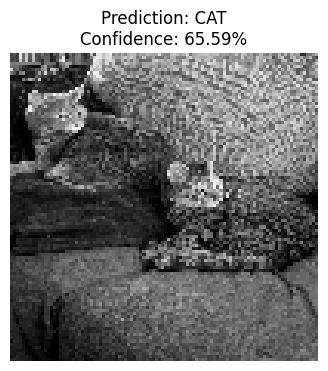

In [ ]:
LOCAL_IMAGE_PATH = "/media/Amy and Maat.jpg"

try:
    img = load_img(LOCAL_IMAGE_PATH, target_size=(100, 100), color_mode="grayscale")

    img_array = img_to_array(img)
    img_array = img_array / 255.0

    img_batch = np.expand_dims(img_array, axis=0)

    probability = float(model.predict(img_batch))

    if probability >= 0.5:
        prediction_label = "CAT"
        confidence = probability * 100
    else:
        prediction_label = "DOG"
        confidence = (1 - probability) * 100

    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap='gray')
    plt.title(f"Prediction: {prediction_label}\nConfidence: {confidence:.2f}%")
    plt.axis("off")
    plt.show()

except Exception as e:
    print(
        f"Error loading or processing the image in Colab. Details: {e}"
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


/tmp/ipykernel_2480/3054003241.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  probability = float(model.predict(img_batch))


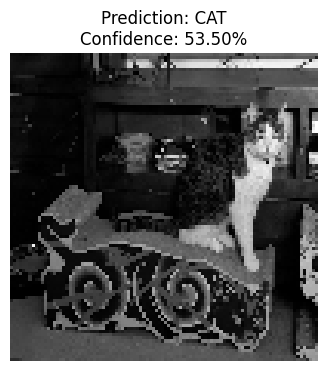

In [ ]:
LOCAL_IMAGE_PATH = "/media/Antrig.jpg"

try:
    img = load_img(LOCAL_IMAGE_PATH, target_size=(100, 100), color_mode="grayscale")

    img_array = img_to_array(img)
    img_array = img_array / 255.0

    img_batch = np.expand_dims(img_array, axis=0)

    probability = float(model.predict(img_batch))

    if probability >= 0.5:
        prediction_label = "CAT"
        confidence = probability * 100
    else:
        prediction_label = "DOG"
        confidence = (1 - probability) * 100

    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap='gray')
    plt.title(f"Prediction: {prediction_label}\nConfidence: {confidence:.2f}%")
    plt.axis("off")
    plt.show()

except Exception as e:
    print(
        f"Error loading or processing the image in Colab. Details: {e}"
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


/tmp/ipykernel_2480/3114599667.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  probability = float(model.predict(img_batch))


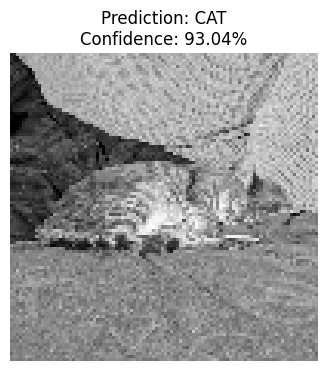

In [ ]:
LOCAL_IMAGE_PATH = "/media/Bella.jpg"

try:
    img = load_img(LOCAL_IMAGE_PATH, target_size=(100, 100), color_mode="grayscale")

    img_array = img_to_array(img)
    img_array = img_array / 255.0

    img_batch = np.expand_dims(img_array, axis=0)

    probability = float(model.predict(img_batch))

    if probability >= 0.5:
        prediction_label = "CAT"
        confidence = probability * 100
    else:
        prediction_label = "DOG"
        confidence = (1 - probability) * 100

    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap='gray')
    plt.title(f"Prediction: {prediction_label}\nConfidence: {confidence:.2f}%")
    plt.axis("off")
    plt.show()

except Exception as e:
    print(
        f"Error loading or processing the image in Colab. Details: {e}"
    )